# Weibull AFT Survival Model: Bayesian vs Frequentist

This notebook compares two implementations of the **Weibull Accelerated Failure Time (AFT)** model on the Anderson leukemia dataset.

| | Approach | Library |
|---|---|---|
| **Frequentist** | Maximum Likelihood Estimation | `lifelines.WeibullAFTFitter` |
| **Bayesian** | MCMC sampling | `bayes_survival.WeibullAFTModel` (PyMC) |

Both share the same survival function:

```
S(t | x) = exp( -(t / exp(X @ beta))^alpha )
```

- `beta` â€” log-scale coefficients; positive value = longer expected survival  
- `alpha` â€” Weibull shape parameter (alpha > 1: increasing hazard, alpha < 1: decreasing hazard)

**Dataset**: 42 leukemia patients â€” time to relapse (weeks), treatment group (`Rx`), sex, and log white blood cell count (`logWBC`).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

from lifelines import WeibullAFTFitter
from lifelines.datasets import load_leukemia

from bayes_survival.survival_models.aft import WeibullAFTModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
az.style.use('arviz-white')

## 1. The Leukemia Dataset

The Anderson (1982) leukemia trial dataset records time to relapse for 42 patients receiving either a placebo or 6-MP treatment.

| Column | Description |
|---|---|
| `t` | Time to relapse or censoring (weeks) |
| `status` | 1 = relapse observed, 0 = censored |
| `sex` | Patient sex (0/1) |
| `logWBC` | Log white blood cell count at baseline |
| `Rx` | Treatment: 0 = 6-MP, 1 = placebo |

In [2]:
df = load_leukemia()
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (42, 5)
Columns: ['t', 'status', 'sex', 'logWBC', 'Rx']


,t,status,sex,logWBC,Rx
0,35,0,1,1.45,0
1,34,0,1,1.47,0
2,32,0,1,2.20,0
3,32,0,1,2.53,0
4,25,0,1,1.78,0
5,23,1,1,2.57,0
6,22,1,1,2.32,0
7,20,0,1,2.01,0
8,19,0,0,2.05,0
9,17,0,0,2.16,0


In [3]:
n_events = int(df['status'].sum())
event_rate = df['status'].mean()
t_min, t_max = df['t'].min(), df['t'].max()

print(f'Observations : {len(df)}')
print(f'Events       : {n_events} ({event_rate:.1%})')
print(f'Time range   : {t_min:.0f} - {t_max:.0f} weeks')
print()
df[['sex', 'logWBC', 'Rx']].describe().round(3)

Observations : 42
Events       : 30 (71.4%)
Time range   : 1 - 35 weeks



,sex,logWBC,Rx
count,42.000,42.000,42.000
mean,0.476,2.930,0.500
std,0.505,0.918,0.506
min,0.000,1.450,0.000
25%,0.000,2.302,0.000
50%,0.000,2.800,0.500
75%,1.000,3.490,1.000
max,1.000,5.000,1.000


## 2. Frequentist Baseline: `lifelines.WeibullAFTFitter`

`WeibullAFTFitter` maximises the log-likelihood directly. With `model_ancillary=False` (default), the shape `alpha` is a single constant.

**Parameterisation note**: lifelines stores the shape on the **log scale** in `params_[('rho_', 'Intercept')]`; `exp(coef)` gives the natural-scale value used for comparison with the Bayesian model.

In [5]:
ll_model = WeibullAFTFitter()
ll_model.fit(df, duration_col='t', event_col='status')
ll_model.print_summary()

<lifelines.WeibullAFTFitter: fitted with 42 total observations, 12 right-censored observations>
             duration col = 't'
                event col = 'status'
   number of observations = 42
number of events observed = 30
           log-likelihood = -89.70
         time fit was run = 2026-04-02 14:07:22 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Rx        -0.72      0.49      0.20           -1.12           -0.33                0.33                0.72
        logWBC    -0.79      0.45      0.11           -1.00           -0.59                0.37                0.56
        sex       -0.16      0.86      0.18           -0.51            0.20                0.60                1.22
        Intercept  5.46    235.60      0.35            4.77            6.15              118.51              468.40
rho_    Intercept  0.81      2.26      0.14            0.53            1.10                1.70                3.00

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Rx           0.00 -3.59 <0.005     11.54
        logWBC       0.00 -7.54 <0.005     44.24
        sex          0.00 -0.87   0.38      1.38
        Intercept    0.00 15.58 <0.005    179.37
rho_    Intercept    0.00  5.65 <0.005     25.90
---
Concordance = 0.85
AIC = 189.39
log-likelihood ratio test = 53.42 on 3 df
-log2(p) of ll-ratio test = 35.96

## 3. Bayesian Weibull AFT

`WeibullAFTModel` uses PyMC for MCMC sampling. An intercept column is prepended automatically â€” pass raw covariates only.

**Default priors**:  
- `alpha ~ Gamma(2, 1)` â€” shape parameter (mean = 2, SD â‰ˆ 1.4)  
- `beta ~ Normal(0, 5)` â€” log-scale coefficients (weakly regularising)

In [6]:
X = df[['sex', 'logWBC', 'Rx']].values
t = df['t'].values
event = df['status'].values.astype(int)

print(f'X shape : {X.shape}  (sex, logWBC, Rx)')
print(f't range : {t.min():.1f} - {t.max():.1f}')
print(f'Events  : {event.sum()} / {len(event)}')

X shape : (42, 3)  (sex, logWBC, Rx)
t range : 1.0 - 35.0
Events  : 30 / 42


In [7]:
bayes_model = WeibullAFTModel()

bayes_model.fit(
    X,
    t,
    event,
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.99,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.


In [8]:
# Posterior summary â€” beta[0]=Intercept, beta[1]=sex, beta[2]=logWBC, beta[3]=Rx
az.summary(bayes_model.idata, var_names=['alpha', 'beta'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.112,0.305,1.548,2.716,0.006,0.005,2288.0,2517.0,1.0
beta[0],5.480,0.391,4.730,6.271,0.009,0.006,1865.0,1985.0,1.0
beta[1],-0.135,0.196,-0.513,0.271,0.004,0.003,2727.0,2208.0,1.0
beta[2],-0.782,0.114,-1.003,-0.547,0.003,0.002,2001.0,1773.0,1.0
beta[3],-0.764,0.224,-1.175,-0.306,0.005,0.003,2344.0,1965.0,1.0


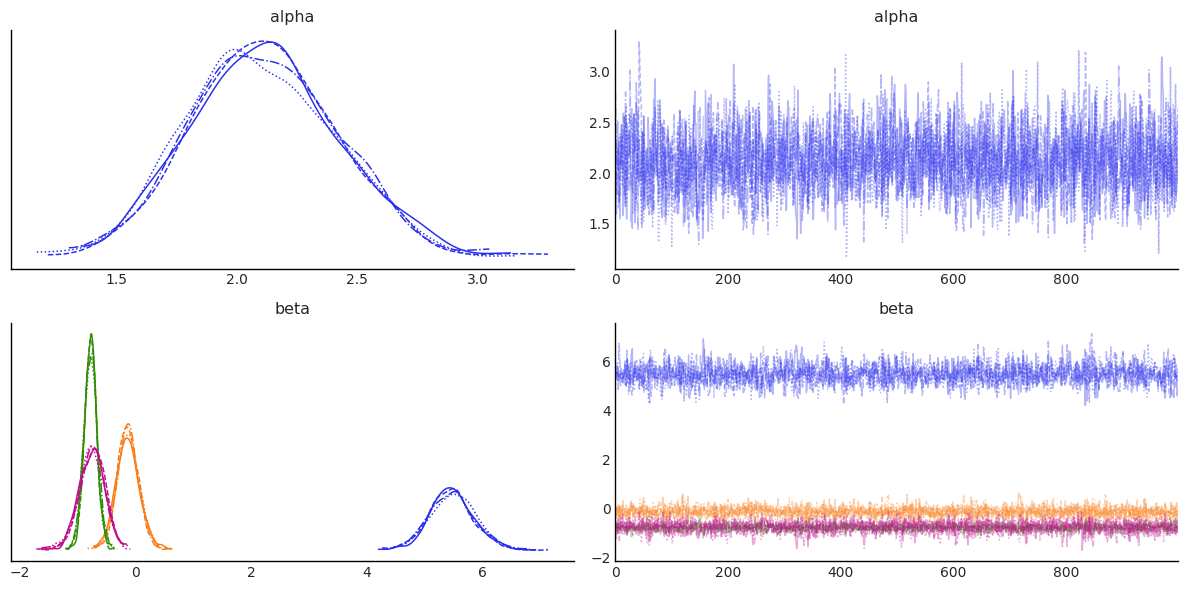

In [9]:
az.plot_trace(bayes_model.idata, var_names=['alpha', 'beta'], compact=True, figsize=(12, 6))
plt.tight_layout()
plt.show()

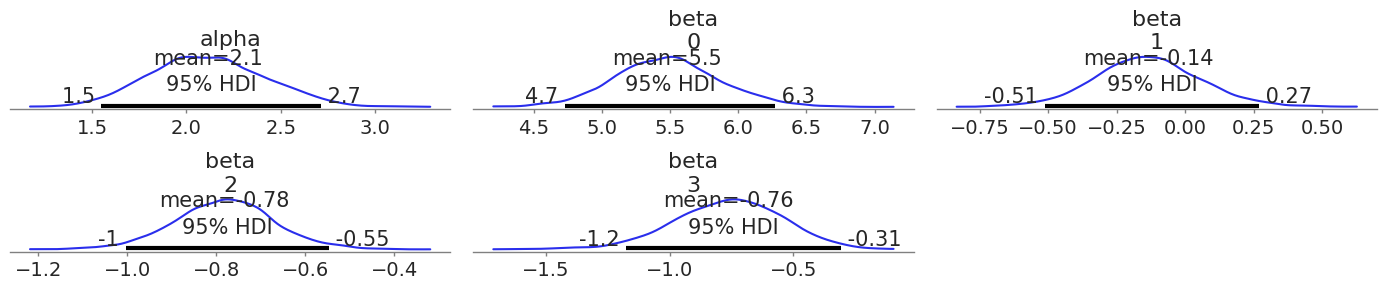

In [10]:
az.plot_posterior(
    bayes_model.idata,
    var_names=['alpha', 'beta'],
    hdi_prob=0.95,
    figsize=(14, 3),
)
plt.tight_layout()
plt.show()

## 4. Coefficient Comparison

We compare the **log-scale coefficients** (which control the Weibull scale `lambda = exp(X @ beta)`) between both approaches.

- **lifelines**: point estimate + asymptotic 95% CI  
- **Bayesian**: posterior mean + 95% HDI

For the shape parameter, lifelines stores `log(alpha)` in `rho_`; we exponentiate to match the Bayesian `alpha` which is on the natural scale.

In [11]:
ll_summary = ll_model.summary
bayes_sum = az.summary(bayes_model.idata, var_names=['alpha', 'beta'], hdi_prob=0.95)

# Dynamically find CI column names (robust to lifelines version differences)
lower_col = next(c for c in ll_summary.columns if 'lower' in c and 'exp' not in c)
upper_col = next(c for c in ll_summary.columns if 'upper' in c and 'exp' not in c)

cov_names = ['Intercept', 'sex', 'logWBC', 'Rx']
param_labels = ['beta[0] â€” Intercept', 'beta[1] â€” sex', 'beta[2] â€” logWBC', 'beta[3] â€” Rx']

rows = []
for i, (ll_key, label) in enumerate(zip(cov_names, param_labels)):
    ll_row = ll_summary.loc[('lambda_', ll_key)]
    bk = 'beta[{}]'.format(i)
    rows.append({
        'Parameter': label,
        'lifelines MLE': round(ll_row['coef'], 3),
        'lifelines 95% CI': '[{:.3f}, {:.3f}]'.format(ll_row[lower_col], ll_row[upper_col]),
        'Bayes mean': round(bayes_sum.loc[bk, 'mean'], 3),
        'Bayes 95% HDI': '[{:.3f}, {:.3f}]'.format(bayes_sum.loc[bk, 'hdi_2.5%'], bayes_sum.loc[bk, 'hdi_97.5%']),
    })

# Shape parameter: lifelines stores log(alpha), Bayes stores alpha directly
ll_rho = ll_summary.loc[('rho_', 'Intercept')]
rows.append({
    'Parameter': 'alpha â€” shape',
    'lifelines MLE': round(np.exp(ll_rho['coef']), 3),
    'lifelines 95% CI': '[{:.3f}, {:.3f}]'.format(np.exp(ll_rho[lower_col]), np.exp(ll_rho[upper_col])),
    'Bayes mean': round(bayes_sum.loc['alpha', 'mean'], 3),
    'Bayes 95% HDI': '[{:.3f}, {:.3f}]'.format(bayes_sum.loc['alpha', 'hdi_2.5%'], bayes_sum.loc['alpha', 'hdi_97.5%']),
})

pd.DataFrame(rows).set_index('Parameter')

,lifelines MLE,lifelines 95% CI,Bayes mean,Bayes 95% HDI
Parameter,,,,
beta[0] â€” Intercept,5.462,"[4.775, 6.149]",5.480,"[4.730, 6.271]"
beta[1] â€” sex,-0.156,"[-0.508, 0.195]",-0.135,"[-0.513, 0.271]"
beta[2] â€” logWBC,-0.792,"[-0.998, -0.586]",-0.782,"[-1.003, -0.547]"
beta[3] â€” Rx,-0.722,"[-1.117, -0.327]",-0.764,"[-1.175, -0.306]"
alpha â€” shape,2.258,"[1.702, 2.995]",2.112,"[1.548, 2.716]"


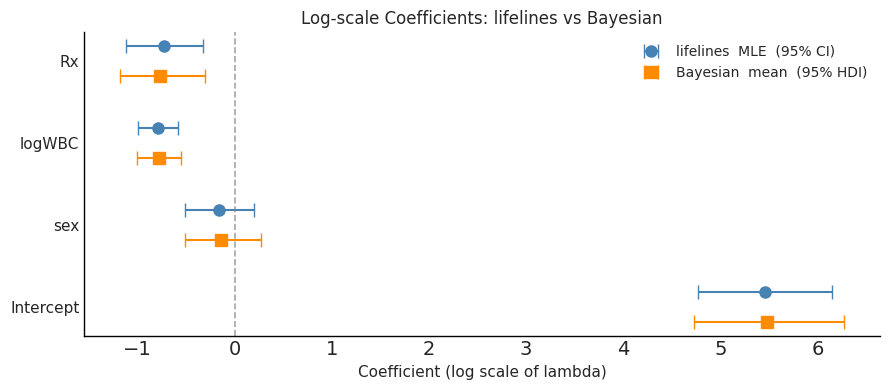

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

display_names = ['Intercept', 'sex', 'logWBC', 'Rx']
ll_keys = [('lambda_', k) for k in display_names]
bayes_keys = ['beta[{}]'.format(i) for i in range(4)]
y_pos = np.arange(len(display_names))
offset = 0.18

for i, (ll_key, bk) in enumerate(zip(ll_keys, bayes_keys)):
    ll_row = ll_summary.loc[ll_key]
    ll_c, ll_lo, ll_hi = ll_row['coef'], ll_row[lower_col], ll_row[upper_col]
    ax.errorbar(
        ll_c, y_pos[i] + offset,
        xerr=[[ll_c - ll_lo], [ll_hi - ll_c]],
        fmt='o', color='steelblue', ms=8, capsize=5, lw=1.5,
        label='lifelines  MLE  (95% CI)' if i == 0 else '',
    )
    b_mean = bayes_sum.loc[bk, 'mean']
    b_lo   = bayes_sum.loc[bk, 'hdi_2.5%']
    b_hi   = bayes_sum.loc[bk, 'hdi_97.5%']
    ax.errorbar(
        b_mean, y_pos[i] - offset,
        xerr=[[b_mean - b_lo], [b_hi - b_mean]],
        fmt='s', color='darkorange', ms=8, capsize=5, lw=1.5,
        label='Bayesian  mean  (95% HDI)' if i == 0 else '',
    )

ax.axvline(0, color='grey', linestyle='--', lw=1.2, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(display_names, fontsize=11)
ax.set_xlabel('Coefficient (log scale of lambda)', fontsize=11)
ax.set_title('Log-scale Coefficients: lifelines vs Bayesian', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Survival Function Comparison

We compare predicted survival curves for three clinically interpretable profiles:

| Profile | sex | logWBC | Rx | Expected outcome |
|---|---|---|---|---|
| Treated, low WBC | 1 | 25th percentile | 0 (6-MP) | Best prognosis |
| Treated, high WBC | 1 | 75th percentile | 0 (6-MP) | Intermediate |
| Control, high WBC | 1 | 75th percentile | 1 (placebo) | Worst prognosis |

The **shaded region** shows the Bayesian 95% HDI â€” a direct measure of posterior predictive uncertainty absent from the frequentist point estimate.

In [13]:
logWBC_q25 = df['logWBC'].quantile(0.25)
logWBC_q75 = df['logWBC'].quantile(0.75)

profiles = pd.DataFrame({
    'sex':    [1,          1,          1],
    'logWBC': [logWBC_q25, logWBC_q75, logWBC_q75],
    'Rx':     [0,          0,          1],
}, index=['Treated, low WBC', 'Treated, high WBC', 'Control, high WBC'])

print('Test profiles:')
print(profiles.round(3))

Test profiles:
                   sex  logWBC  Rx
Treated, low WBC     1   2.302   0
Treated, high WBC    1   3.490   0
Control, high WBC    1   3.490   1


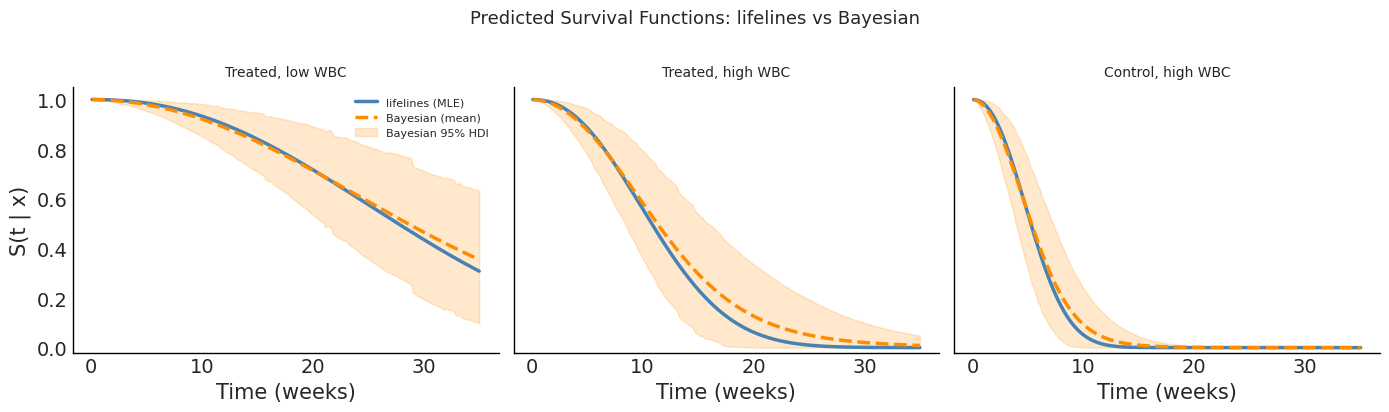

In [14]:
eval_times = np.linspace(0.1, df['t'].max(), 200)

# Lifelines: predict_survival_function returns DataFrame (times x profiles)
surv_ll = ll_model.predict_survival_function(profiles, times=eval_times)

# Bayesian: returns SurvivalPrediction with mean/hdi_lower/hdi_upper of shape (n_profiles, n_times)
bayes_pred = bayes_model.predict_survival_function(profiles.values, eval_times, hdi_prob=0.95)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for i, (ax, profile_label) in enumerate(zip(axes, profiles.index)):
    # lifelines â€” single deterministic curve
    ax.plot(
        eval_times, surv_ll.iloc[:, i],
        color='steelblue', lw=2.5, label='lifelines (MLE)',
    )
    # Bayesian â€” posterior mean + HDI envelope
    ax.plot(
        bayes_pred.times, bayes_pred.mean[i],
        color='darkorange', lw=2.5, ls='--', label='Bayesian (mean)',
    )
    ax.fill_between(
        bayes_pred.times,
        bayes_pred.hdi_lower[i],
        bayes_pred.hdi_upper[i],
        color='darkorange', alpha=0.2, label='Bayesian 95% HDI',
    )
    ax.set_title(profile_label, fontsize=10, pad=8)
    ax.set_xlabel('Time (weeks)')
    ax.set_ylim(-0.02, 1.05)
    if i == 0:
        ax.set_ylabel('S(t | x)')
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Predicted Survival Functions: lifelines vs Bayesian', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# HDI width at selected time points â€” quantifying Bayesian uncertainty
check_times_idx = [25, 100, 175]  # ~12%, 50%, 87% along the time axis
check_times = eval_times[check_times_idx]

rows_unc = []
for i, label in enumerate(profiles.index):
    for j, ti in zip(check_times_idx, check_times):
        width = bayes_pred.hdi_upper[i, j] - bayes_pred.hdi_lower[i, j]
        rows_unc.append({
            'Profile': label,
            'Time (weeks)': round(ti, 1),
            'lifelines S(t)': round(float(surv_ll.iloc[j, i]), 3),
            'Bayes mean S(t)': round(float(bayes_pred.mean[i, j]), 3),
            'HDI width': round(float(width), 3),
        })

pd.DataFrame(rows_unc)

,Profile,Time (weeks),lifelines S(t),Bayes mean S(t),HDI width
0,"Treated, low WBC",4.5,0.989,0.983,0.036
1,"Treated, low WBC",17.6,0.778,0.771,0.297
2,"Treated, low WBC",30.8,0.414,0.447,0.522
3,"Treated, high WBC",4.5,0.909,0.900,0.158
4,"Treated, high WBC",17.6,0.123,0.193,0.418
5,"Treated, high WBC",30.8,0.001,0.018,0.089
6,"Control, high WBC",4.5,0.616,0.612,0.417
7,"Control, high WBC",17.6,0.000,0.003,0.016
8,"Control, high WBC",30.8,0.000,0.000,0.000


## Summary

| Aspect | `lifelines` (MLE) | `bayes_survival` (MCMC) |
|---|---|---|
| Coefficients | Point estimates | Full posterior distribution |
| Uncertainty | Asymptotic 95% CI | Exact 95% HDI |
| Shape parameter | Reported as `log(alpha)` in `rho_` | Sampled directly as `alpha` |
| Priors | None | `alpha ~ Gamma(5, 2)`, `beta ~ N(0,5)` |
| Compute time | Seconds (MLE) | Minutes (MCMC) |
| Prediction | Single curve | Posterior predictive envelope |

**Key observations from this dataset:**
- Both models recover near-identical coefficient estimates, validating the implementation.
- Treatment (`Rx`) has a large negative coefficient â€” going from 6-MP (Rx=0) to placebo (Rx=1) substantially shortens expected survival.
- `logWBC` has a strong negative coefficient â€” high WBC at baseline is a poor prognostic marker.
- The Bayesian HDI envelope widens at later time points, correctly reflecting greater uncertainty in the tail of the survival distribution where little data exists.
- With only 42 observations, the wider Bayesian priors provide mild regularisation, resulting in slightly shrunk coefficient estimates compared to MLE.